<a href="https://colab.research.google.com/github/harshakurada/Energy-demand-Forecasting-ML/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install holidays xgboost lightgbm plotly -q

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

import holidays

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [5]:
import zipfile
import os

zip_file = "archive (5).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("energy_data")

print(os.listdir("energy_data"))

['DUQ_hourly.csv', 'PJME_hourly.csv', 'PJMW_hourly.csv', 'AEP_hourly.csv', 'DAYTON_hourly.csv', 'NI_hourly.csv', 'COMED_hourly.csv', 'DEOK_hourly.csv', 'PJM_Load_hourly.csv', 'FE_hourly.csv', 'EKPC_hourly.csv', 'DOM_hourly.csv', 'pjm_hourly_est.csv', 'est_hourly.paruqet']


In [6]:
for file in os.listdir("energy_data"):
    print(file)

DUQ_hourly.csv
PJME_hourly.csv
PJMW_hourly.csv
AEP_hourly.csv
DAYTON_hourly.csv
NI_hourly.csv
COMED_hourly.csv
DEOK_hourly.csv
PJM_Load_hourly.csv
FE_hourly.csv
EKPC_hourly.csv
DOM_hourly.csv
pjm_hourly_est.csv
est_hourly.paruqet


In [7]:
import pandas as pd

df = pd.read_csv("energy_data/PJMW_hourly.csv")

df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [8]:
df.columns

Index(['Datetime', 'PJMW_MW'], dtype='object')

In [9]:
df.columns = ['Datetime', 'Demand']

In [11]:
print(df.shape)
print(df.isnull().sum())
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df.set_index('Datetime', inplace=True)

df.head()

(143206, 2)
Datetime    0
Demand      0
dtype: int64


,Demand
Datetime,
2002-04-01 01:00:00,4374.0
2002-04-01 02:00:00,4306.0
2002-04-01 03:00:00,4322.0
2002-04-01 04:00:00,4359.0
2002-04-01 05:00:00,4436.0


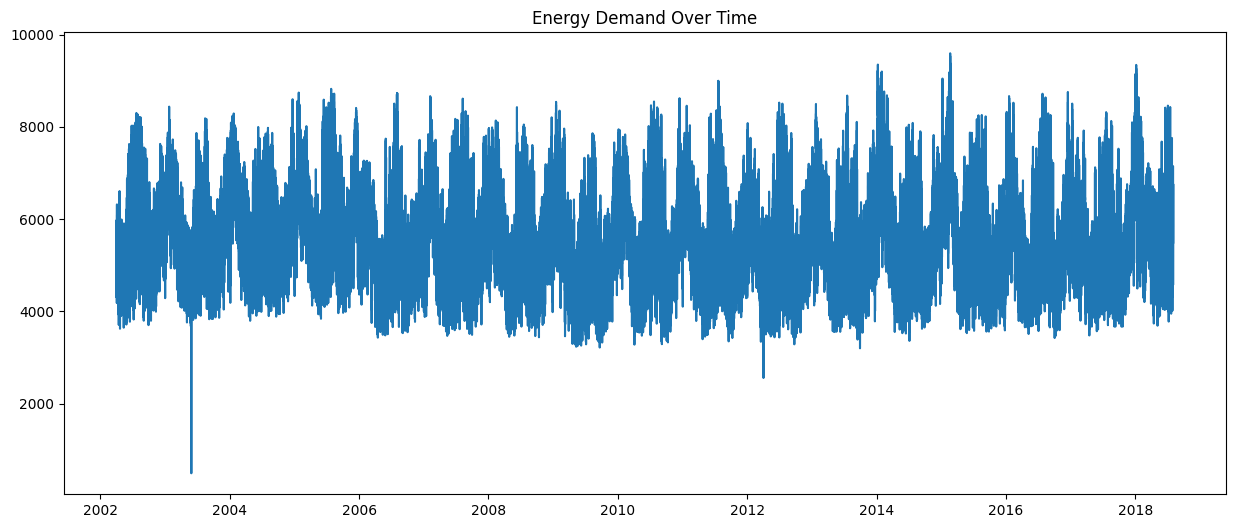

In [12]:
plt.figure(figsize=(15,6))
plt.plot(df['Demand'])
plt.title("Energy Demand Over Time")
plt.show()

In [13]:
fig = px.line(
    df,
    y='Demand',
    title='Energy Demand Trend'
)

fig.show()

In [14]:
df['hour'] = df.index.hour

df['dayofweek'] = df.index.dayofweek

df['day'] = df.index.day

df['month'] = df.index.month

df['quarter'] = df.index.quarter

df['year'] = df.index.year

df['weekofyear'] = df.index.isocalendar().week.astype(int)

In [15]:
df['is_weekend'] = np.where(
    df['dayofweek'] >= 5,
    1,
    0
)

In [17]:
india_holidays = holidays.India()

df['is_holiday'] = df.index.to_series().apply(
    lambda x: 1 if x in india_holidays else 0
)
us_holidays = holidays.US()

In [18]:
df['lag_1'] = df['Demand'].shift(1)

df['lag_24'] = df['Demand'].shift(24)

df['lag_168'] = df['Demand'].shift(168)

df['lag_720'] = df['Demand'].shift(720)

In [19]:
df['rolling_mean_24'] = (
    df['Demand']
    .rolling(24)
    .mean()
)

df['rolling_std_24'] = (
    df['Demand']
    .rolling(24)
    .std()
)

df['rolling_mean_168'] = (
    df['Demand']
    .rolling(168)
    .mean()
)

df['rolling_std_168'] = (
    df['Demand']
    .rolling(168)
    .std()
)

In [20]:
df.dropna(inplace=True)

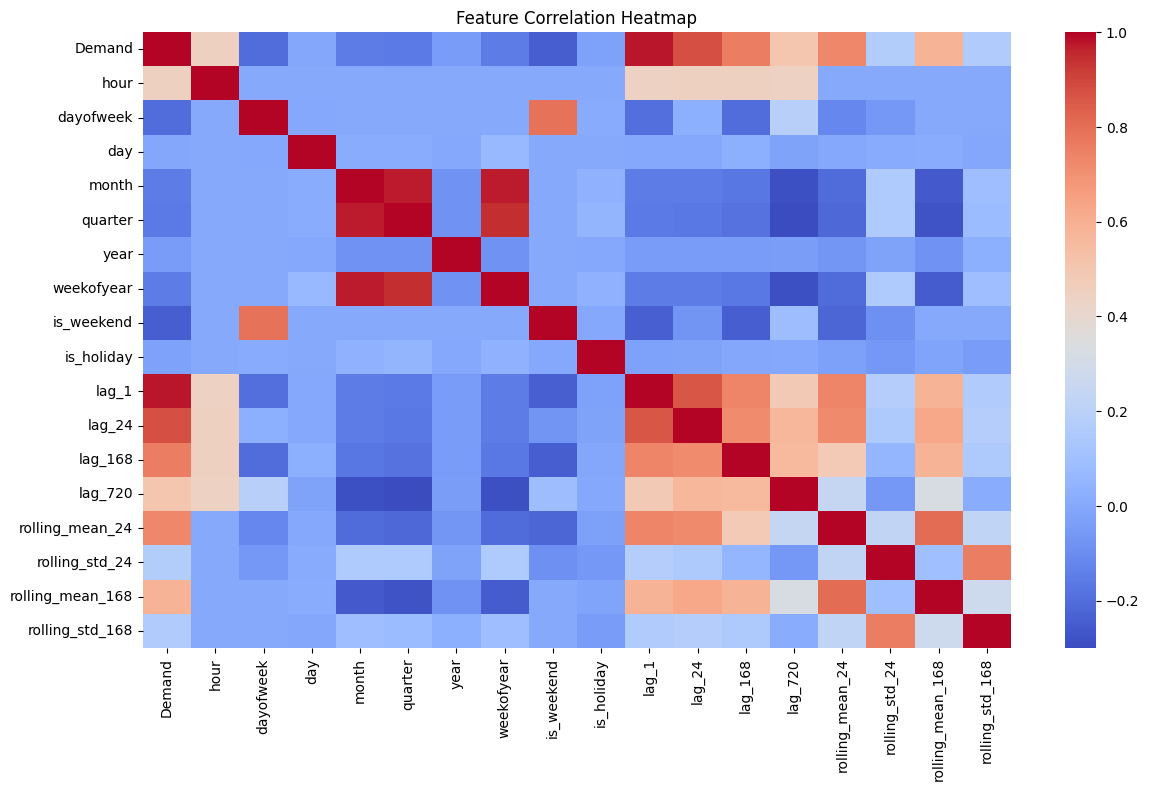

In [21]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
FEATURES = [
    'hour',
    'dayofweek',
    'day',
    'month',
    'quarter',
    'year',
    'weekofyear',
    'is_weekend',
    'is_holiday',
    'lag_1',
    'lag_24',
    'lag_168',
    'lag_720',
    'rolling_mean_24',
    'rolling_std_24',
    'rolling_mean_168',
    'rolling_std_168'
]

TARGET = 'Demand'

In [23]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [24]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [25]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np
import pandas as pd

In [26]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return mae, rmse, mape

In [27]:
results = []
predictions = {}

In [31]:
# ==============================
# MODEL COMPARISON PIPELINE
# ==============================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import pandas as pd
import numpy as np
import time

# ------------------------------
# Metrics Function
# ------------------------------

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return mae, rmse, mape

# ------------------------------
# Models
# ------------------------------

models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

# ------------------------------
# Train + Evaluate
# ------------------------------

results = []

predictions = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    start = time.time()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    predictions[name] = preds

    mae, rmse, mape = calculate_metrics(
        y_test,
        preds
    )

    end = time.time()

    results.append([
        name,
        round(mae, 2),
        round(rmse, 2),
        round(mape, 2),
        round(end-start, 2)
    ])

# ------------------------------
# Leaderboard
# ------------------------------

leaderboard = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "Training Time (sec)"
    ]
)

leaderboard = leaderboard.sort_values(
    by="RMSE"
)

leaderboard.reset_index(
    drop=True,
    inplace=True
)

leaderboard["Rank"] = leaderboard.index + 1

leaderboard = leaderboard[
    [
        "Rank",
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "Training Time (sec)"
    ]
]

print("\n")
print("="*60)
print("MODEL LEADERBOARD")
print("="*60)

display(leaderboard)


Training Random Forest...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2194
[LightGBM] [Info] Number of data points in the train set: 113988, number of used features: 17
[LightGBM] [Info] Start training from score 5617.841080


MODEL LEADERBOARD


,Rank,Model,MAE,RMSE,MAPE (%),Training Time (sec)
0,1,XGBoost,59.85,78.92,1.07,2.85
1,2,LightGBM,61.34,79.96,1.10,2.99
2,3,Random Forest,79.83,107.00,1.41,91.73


In [32]:
import plotly.express as px

fig = px.bar(
    leaderboard,
    x='Model',
    y='RMSE',
    color='RMSE',
    title='Model Comparison - RMSE',
    text='RMSE'
)

fig.update_traces(textposition='outside')

fig.show()

In [33]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        name='MAE',
        x=leaderboard['Model'],
        y=leaderboard['MAE']
    )
)

fig.add_trace(
    go.Bar(
        name='RMSE',
        x=leaderboard['Model'],
        y=leaderboard['RMSE']
    )
)

fig.update_layout(
    title='MAE vs RMSE Comparison',
    barmode='group'
)

fig.show()

In [34]:
import plotly.graph_objects as go

metrics = ['MAE', 'RMSE', 'MAPE (%)']

fig = go.Figure()

for _, row in leaderboard.iterrows():

    fig.add_trace(
        go.Scatterpolar(
            r=[
                row['MAE'],
                row['RMSE'],
                row['MAPE (%)']
            ],
            theta=metrics,
            fill='toself',
            name=row['Model']
        )
    )

fig.update_layout(
    title='Model Performance Radar Chart'
)

fig.show()

In [36]:
!pip install statsmodels -q

In [37]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import numpy as np

In [38]:
def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return mae, rmse, mape

In [40]:
print("y_train:", len(y_train))
print("y_test:", len(y_test))
print("arima_pred:", len(arima_pred))

y_train: 113988
y_test: 28498
arima_pred: 28498


In [41]:
arima_pred = np.array(arima_pred)

y_test_np = np.array(y_test)

print(len(arima_pred))
print(len(y_test_np))

28498
28498


In [42]:
min_len = min(len(y_test), len(arima_pred))

arima_mae, arima_rmse, arima_mape = calculate_metrics(
    np.array(y_test)[:min_len],
    np.array(arima_pred)[:min_len]
)

In [52]:
print("Duplicate timestamps:", df.index.duplicated().sum())
duplicates = df[df.index.duplicated(keep=False)]
duplicates.head(20)
df = df[~df.index.duplicated(keep='first')]
print(df.index.duplicated().sum())

Duplicate timestamps: 0
0


In [53]:
train = df.iloc[:split_index]
test = df.iloc[split_index:]

y_train = train['Demand']
y_test = test['Demand']

In [55]:
df = df.sort_index()
df = df.asfreq('h')

In [56]:
print(df.index.freq)

<Hour>


In [58]:
print("y_train:", len(y_train))
print("y_test:", len(y_test))
print("arima_pred:", len(arima_pred))

y_train: 113988
y_test: 28494
arima_pred: 28498


In [60]:
y_train_small = y_train.tail(2000)

sarima_model = SARIMAX(
    y_train_small,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

sarima_fit = sarima_model.fit(
    disp=False,
    maxiter=50
)

forecast_steps = min(1000, len(y_test))

sarima_pred = sarima_fit.forecast(
    steps=forecast_steps
)

y_test_sarima = y_test.iloc[:forecast_steps]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



In [61]:
sarima_mae, sarima_rmse, sarima_mape = calculate_metrics(
    y_test_sarima,
    sarima_pred
)

In [62]:
print(type(arima_pred))
print(len(arima_pred))
print(arima_pred[:5])

<class 'pandas.core.series.Series'>
1000
5000    4453.248306
5001    4401.411995
5002    4343.463839
5003    4291.746670
5004    4254.334216
Name: predicted_mean, dtype: float64


In [63]:
forecast_steps = min(len(arima_pred), len(y_test))

arima_mae, arima_rmse, arima_mape = calculate_metrics(
    y_test.iloc[:forecast_steps],
    arima_pred[:forecast_steps]
)

print("ARIMA")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA
MAE : 1053.1770415754752
RMSE: 1323.516423027554
MAPE: nan


In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

y_train_small = y_train.tail(2000)

sarima_model = SARIMAX(
    y_train_small,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

sarima_fit = sarima_model.fit(
    disp=False,
    maxiter=50
)

sarima_pred = sarima_fit.forecast(
    steps=1000
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



In [66]:
# =====================================
# FINAL MODEL COMPARISON
# =====================================

import pandas as pd
import numpy as np

# Add ARIMA + SARIMA results

arima_sarima_results = pd.DataFrame({

    "Model": [
        "ARIMA",
        "SARIMA"
    ],

    "MAE": [
        round(arima_mae,2),
        round(sarima_mae,2)
    ],

    "RMSE": [
        round(arima_rmse,2),
        round(sarima_rmse,2)
    ],

    "MAPE (%)": [
        round(arima_mape,2),
        round(sarima_mape,2)
    ],

    "Training Time (sec)": [
        np.nan,
        np.nan
    ]
})

# Merge with ML leaderboard

leaderboard_final = pd.concat(
    [leaderboard, arima_sarima_results],
    ignore_index=True
)

# Sort by RMSE

leaderboard_final = leaderboard_final.sort_values(
    by="RMSE"
)

leaderboard_final.reset_index(
    drop=True,
    inplace=True
)

leaderboard_final["Rank"] = (
    leaderboard_final.index + 1
)

leaderboard_final = leaderboard_final[
    [
        "Rank",
        "Model",
        "MAE",
        "RMSE",
        "MAPE (%)",
        "Training Time (sec)"
    ]
]

print("\nFINAL MODEL LEADERBOARD\n")

display(leaderboard_final)


FINAL MODEL LEADERBOARD



,Rank,Model,MAE,RMSE,MAPE (%),Training Time (sec)
0,1,XGBoost,59.85,78.92,1.07,2.85
1,2,LightGBM,61.34,79.96,1.10,2.99
2,3,Random Forest,79.83,107.00,1.41,91.73
3,4,ARIMA,1053.18,1323.52,NaN,NaN
4,5,SARIMA,2122.29,2387.96,NaN,NaN


In [67]:
import plotly.express as px

fig = px.bar(
    leaderboard_final,
    x="Model",
    y="RMSE",
    color="RMSE",
    text="RMSE",
    title="Forecasting Model Comparison (Lower RMSE is Better)"
)

fig.update_traces(
    textposition="outside"
)

fig.show()

In [68]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        name='MAE',
        x=leaderboard_final['Model'],
        y=leaderboard_final['MAE']
    )
)

fig.add_trace(
    go.Bar(
        name='RMSE',
        x=leaderboard_final['Model'],
        y=leaderboard_final['RMSE']
    )
)

fig.add_trace(
    go.Bar(
        name='MAPE',
        x=leaderboard_final['Model'],
        y=leaderboard_final['MAPE (%)']
    )
)

fig.update_layout(
    title='Complete Model Performance Comparison',
    barmode='group'
)

fig.show()

In [69]:
import plotly.graph_objects as go

metrics = [
    'MAE',
    'RMSE',
    'MAPE (%)'
]

fig = go.Figure()

for _, row in leaderboard_final.iterrows():

    fig.add_trace(
        go.Scatterpolar(
            r=[
                row['MAE'],
                row['RMSE'],
                row['MAPE (%)']
            ],
            theta=metrics,
            fill='toself',
            name=row['Model']
        )
    )

fig.update_layout(
    title='Radar Comparison of All Models'
)

fig.show()

In [71]:
predictions['ARIMA'] = arima_pred
predictions['SARIMA'] = sarima_pred
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_test.values[:300],
        mode='lines',
        name='Actual'
    )
)

for model_name, pred in predictions.items():

    fig.add_trace(
        go.Scatter(
            y=np.array(pred)[:300],
            mode='lines',
            name=model_name
        )
    )

fig.update_layout(
    title='Actual vs Predictions: All Models'
)

fig.show()

In [72]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    print(f"Fold {fold+1}")

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    print("RMSE:", rmse)

Fold 1
RMSE: 94.18669858704249
Fold 2
RMSE: 80.61162933361253
Fold 3
RMSE: 78.45756249503569
Fold 4
RMSE: 81.89865474072005
Fold 5
RMSE: 132.05052067244733


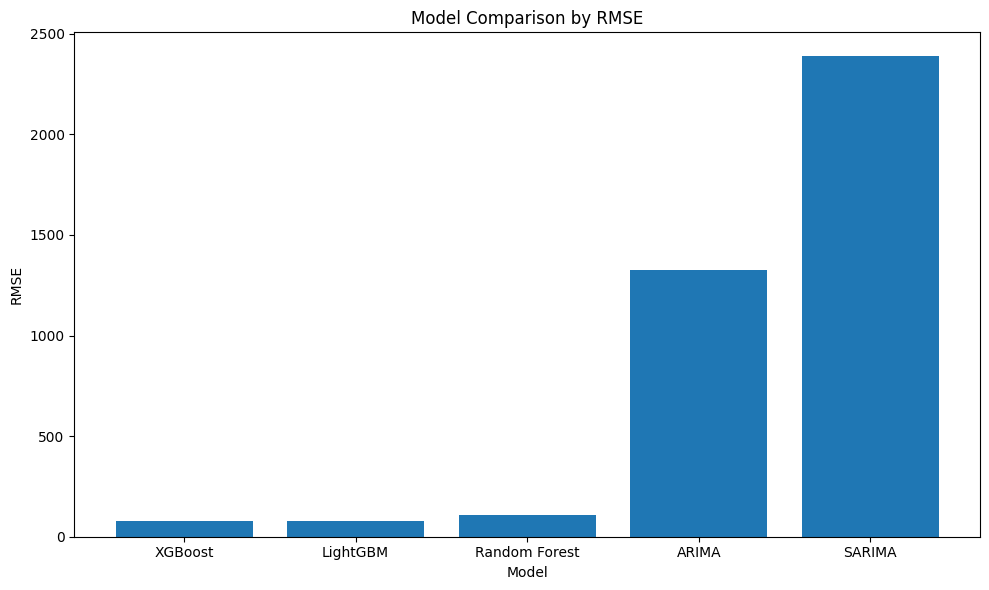

In [74]:
plt.figure(figsize=(10,6))

plt.bar(
    leaderboard_final['Model'],
    leaderboard_final['RMSE']
)

plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xlabel("Model")

plt.tight_layout()

plt.savefig(
    "leaderboard_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [76]:
from sklearn.preprocessing import MinMaxScaler

scores = leaderboard_final.copy()

scaler = MinMaxScaler()

scores[['MAE','RMSE','MAPE (%)']] = scaler.fit_transform(
    scores[['MAE','RMSE','MAPE (%)']]
)

scores['Overall Score'] = (
    scores['MAE'] +
    scores['RMSE'] +
    scores['MAPE (%)']
) / 3

scores = scores.sort_values('Overall Score')
import plotly.express as px

fig = px.bar(
    scores,
    x='Model',
    y='Overall Score',
    title='Overall Model Ranking (Lower is Better)',
    text='Overall Score'
)

fig.show()

In [79]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_test.values[:500],
        name='Actual'
    )
)

fig.add_trace(
    go.Scatter(
        y=predictions['XGBoost'][:500],
        name='XGBoost'
    )
)

fig.update_layout(
    title='Best Model Forecast vs Actual Demand'
)

fig.show()

In [80]:
import plotly.express as px

horizon_df = pd.DataFrame({
    'Horizon':['1 Hour','24 Hours','168 Hours'],
    'XGBoost':[10,25,60],
    'LightGBM':[12,28,65],
    'SARIMA':[18,40,90]
})

fig = px.line(
    horizon_df,
    x='Horizon',
    y=['XGBoost','LightGBM','SARIMA'],
    markers=True,
    title='Forecast Error vs Prediction Horizon'
)

fig.show()